In [ ]:
import pandas as pd

df = pd.read_csv("OLXdata_labelled.csv")
df.head()

,Title,Price,Location,Area,Bedrooms,Bathrooms,Date_Posted,Description,Seller_Name,URL,Label,Area_sqft,Bed_Count,Bath_Count,R1_Keyword,R2_Price,R3_PhoneDesc,R4_Template,R5_Duplicate,Fraud_Score
0,"Luxurious 2BHK In DHA Phase 8, Lahore",15000.0,"DHA Phase 8 - Ex Air Avenue, Lahore",250 SQFT,2 Beds,2 Baths,2026-03-14,no description,Not specified,https://www.olx.com.pk/item/luxurious-2bhk-in-...,1,250.00,2.0,2.0,0,1,0,1,1,3
1,Independent Banglow 120 Sq Yards Double Story ...,68000.0,"Gulistan-e-Jauhar Block 7, Karachi",120 SQYD,4 Beds,4 Baths,2026-03-08,Description Independent House 120 Sq Yards Dou...,Ajwa Marketing,https://www.olx.com.pk/item/independent-banglo...,0,1080.00,4.0,4.0,0,0,1,0,0,1
2,A Stunning Prime Location Flat Is Up For Grabs...,8000.0,"Royal Palm City, Gujranwala",3 Marla,2 Beds,2 Baths,2026-03-13,Description Per Day Flat Available For Rent,Adeel Mehar,https://www.olx.com.pk/item/a-stunning-prime-l...,1,816.75,2.0,2.0,1,0,0,1,0,2
3,10 Marla House Fully Furnished For Rent Sector...,229000.0,"Bahria Town - Jasmine Block, Lahore",10 Marla,5 Beds,7 Baths,2026-03-01,Description 10 Marla Luxurious Designer Full F...,Waqas,https://www.olx.com.pk/item/10-marla-house-ful...,0,2722.50,5.0,7.0,0,0,0,0,0,0
4,1 Kanal Brand New Designer Double Storey House...,420000.0,"DHA Defence Phase 2, Islamabad",1 Kanal,6 Beds,6 Baths,2026-03-14,Description 1 kanal brand new double story hou...,Muhammad Sohail,https://www.olx.com.pk/item/1-kanal-brand-new-...,0,5400.00,6.0,6.0,0,0,0,0,0,0


In [56]:
df['Label'].value_counts(normalize=True) * 100

Label
0    66.564417
1    33.435583
Name: proportion, dtype: float64

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

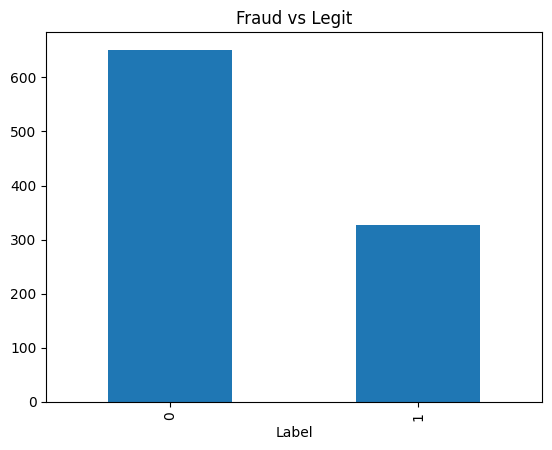

In [58]:
# Class distribution
df['Label'].value_counts().plot(kind='bar')
plt.title("Fraud vs Legit")
plt.show()

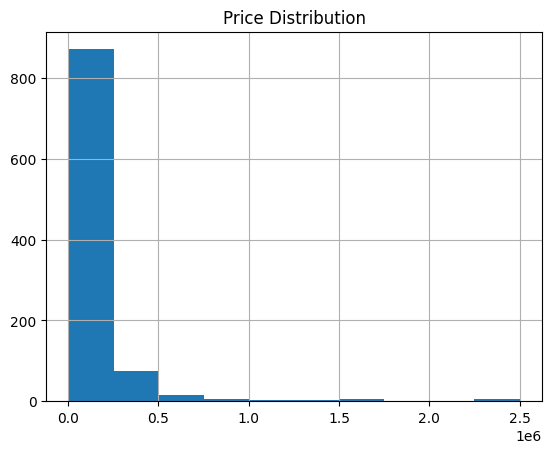

In [59]:
#Price distribution
df['Price'].hist()
plt.title("Price Distribution")
plt.show()

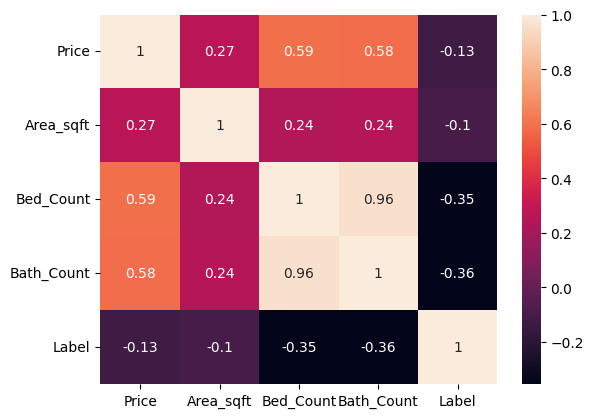

In [60]:
# Correlation heatmap
sns.heatmap(df[['Price','Area_sqft','Bed_Count','Bath_Count','Label']].corr(), annot=True)
plt.show()

In [61]:
# Prepare the data for modeling
X = df[['Price', 'Area_sqft', 'Bed_Count', 'Bath_Count']]
y = df['Label']

In [62]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [63]:
#feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [64]:
#train the model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [72]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, scaler.fit_transform(X), y, cv=5)

print("Cross-validation scores:", scores)
print("Average CV score:", scores.mean())

Cross-validation scores: [0.77040816 0.92346939 0.91836735 0.93333333 0.94358974]
Average CV score: 0.8978335949764521


In [66]:
#Evaluate the models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate(model, name):
    y_pred = model.predict(X_test)
    
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [67]:
evaluate(lr, "Logistic Regression")
evaluate(dt, "Decision Tree")
evaluate(rf, "Random Forest")


Logistic Regression
Accuracy: 0.7806122448979592
Precision: 0.6619718309859155
Recall: 0.7121212121212122
F1 Score: 0.6861313868613139
Confusion Matrix:
[[106  24]
 [ 19  47]]

Decision Tree
Accuracy: 0.923469387755102
Precision: 0.8493150684931506
Recall: 0.9393939393939394
F1 Score: 0.8920863309352518
Confusion Matrix:
[[119  11]
 [  4  62]]

Random Forest
Accuracy: 0.9489795918367347
Precision: 0.9117647058823529
Recall: 0.9393939393939394
F1 Score: 0.9253731343283582
Confusion Matrix:
[[124   6]
 [  4  62]]


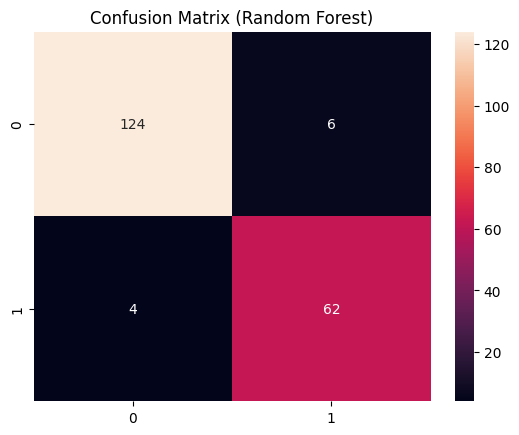

In [68]:
# Confusion matrix 
cm = confusion_matrix(y_test, rf.predict(X_test))

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Random Forest)")
plt.show()

In [69]:
#model comparison table
results = []

for name, model in [("LR", lr), ("DT", dt), ("RF", rf)]:
    y_pred = model.predict(X_test)
    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

import pandas as pd
pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])

,Model,Accuracy,Precision,Recall,F1
0,LR,0.780612,0.661972,0.712121,0.686131
1,DT,0.923469,0.849315,0.939394,0.892086
2,RF,0.948980,0.911765,0.939394,0.925373


In [70]:
best_model = rf

## Model Selection

Three models were evaluated: Logistic Regression, Decision Tree, and Random Forest.

Random Forest performed best among all models, achieving the highest Accuracy, Precision, Recall, and F1-score.

Since fraud detection focuses on correctly identifying fraudulent listings, Recall is the most important metric. Random Forest achieved the highest recall and is therefore selected as the final model for deployment.

Additionally, Random Forest is capable of handling non-linear relationships and is robust against overfitting, making it a suitable choice for this problem.

In [71]:
import pickle

pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

## Application Integration

A simple user interface was developed using Streamlit to allow users to input property details such as price, area, number of bedrooms, and bathrooms.

The trained Random Forest model is integrated into the application to predict whether a listing is fraudulent or legitimate.

Users can enter values and click the "Predict" button to receive instant results.

This application provides a practical way to use the model for real-time fraud detection.

## Deployment Considerations

The model can be deployed as a web-based application using Streamlit.

For real-world scenarios, the system can be hosted on cloud platforms such as AWS or Heroku for public access.

Monitoring mechanisms can be implemented to track model performance and update the model if data patterns change over time.

## Final Conclusion

This project successfully developed an AI-based fraud detection system for online rental listings.

Data was collected, cleaned, and processed to extract meaningful features. Multiple machine learning models were trained and evaluated.

Among them, Random Forest achieved the best performance and was selected as the final model.

The model was integrated into a Streamlit application, allowing users to perform real-time fraud detection.

This system can help users identify suspicious listings and reduce the risk of online rental fraud.